
**Project Title:**
### The Effects of Aerobic Exercise in Patients with Stroke on Cardiorespiratory Fitness and Metabolic Risk Factors
##### Project Manager — Mona Hejazi
**Organization:** NL Health Services (Health Innovation)  
**Date:** April 2026

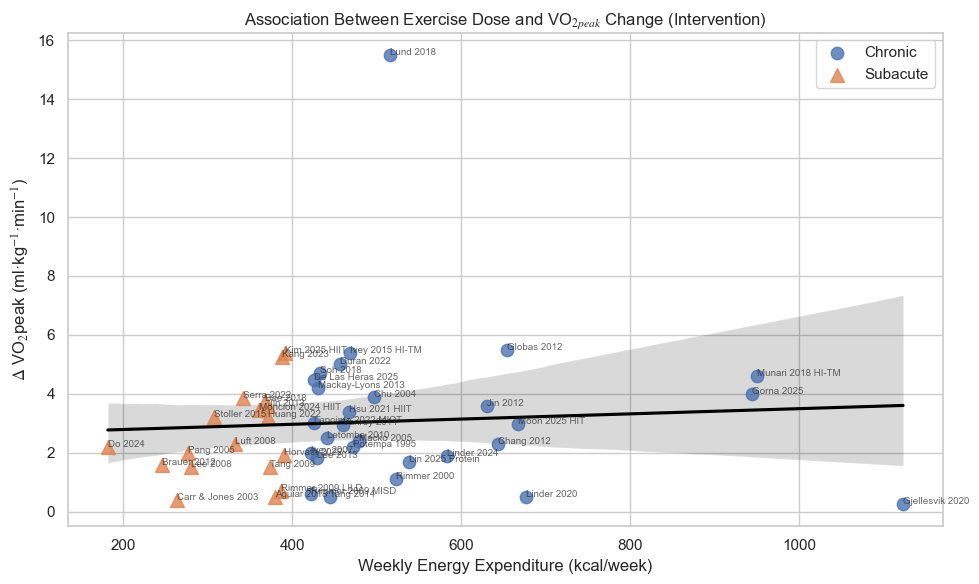

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.unicode_minus"] = False

# Load data
file_path = r"C:\Users\Mona.Hejazi\Documents\Work\Projects\DistillerSR\VO2max_EEE_dataset.xlsx"
df = pd.read_excel(file_path)

# Keep only Intervention rows
df_int = df[df["Group"] == "Intervention"].copy()
df_int = df_int.dropna(subset=["EEE_week_kcal", "Delta_VO2_mean"])

# Phase classification (example rule)
df_int["Phase"] = "Chronic"
df_int.loc[df_int["EEE_week_kcal"] < 400, "Phase"] = "Subacute"

# 🔥 FIX 1: Use proper scientific font + math rendering
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False
})

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

# Regression line + CI
sns.regplot(
    data=df_int,
    x="EEE_week_kcal",
    y="Delta_VO2_mean",
    scatter=False,
    ci=95,
    color="black"
)

# Points
chronic = df_int[df_int["Phase"] == "Chronic"]
subacute = df_int[df_int["Phase"] == "Subacute"]

plt.scatter(chronic["EEE_week_kcal"], chronic["Delta_VO2_mean"],
            marker="o", s=80, label="Chronic", alpha=0.8)

plt.scatter(subacute["EEE_week_kcal"], subacute["Delta_VO2_mean"],
            marker="^", s=100, label="Subacute", alpha=0.8)

# Labels
for _, row in df_int.iterrows():
    plt.text(row["EEE_week_kcal"], row["Delta_VO2_mean"],
             row["Study"], fontsize=7, alpha=0.7)

# 🔥 FIX 2: Use LaTeX-style labels (this fixes VO₂ and superscripts)
plt.xlabel("Weekly Energy Expenditure (kcal/week)")
plt.ylabel(r"$\Delta$ VO$_2$peak (ml·kg$^{-1}$·min$^{-1}$)")
plt.title(r"Association Between Exercise Dose and VO$_{2peak}$ Change (Intervention)")

plt.legend()
plt.tight_layout()
plt.show()

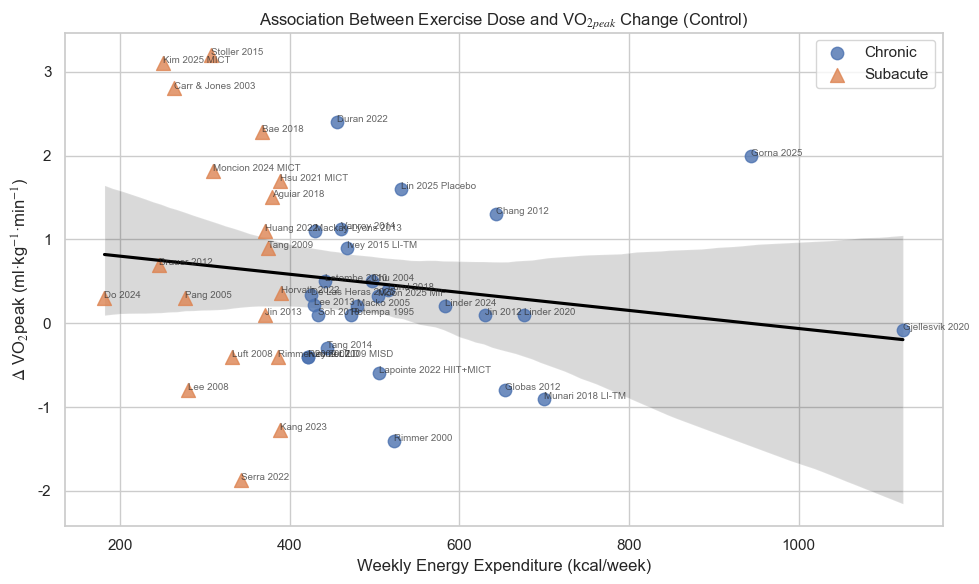

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.unicode_minus"] = False

# Load data
file_path = r"C:\Users\Mona.Hejazi\Documents\Work\Projects\DistillerSR\VO2max_EEE_dataset.xlsx"
df = pd.read_excel(file_path)

# ✅ Keep only CONTROL rows
df_ctrl = df[df["Group"] == "Control"].copy()
df_ctrl = df_ctrl.dropna(subset=["EEE_week_kcal", "Delta_VO2_mean"])

# Phase classification (same logic for consistency)
df_ctrl["Phase"] = "Chronic"
df_ctrl.loc[df_ctrl["EEE_week_kcal"] < 400, "Phase"] = "Subacute"

# Style fixes
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False
})

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

# Regression line + CI
sns.regplot(
    data=df_ctrl,
    x="EEE_week_kcal",
    y="Delta_VO2_mean",
    scatter=False,
    ci=95,
    color="black"
)

# Points
chronic = df_ctrl[df_ctrl["Phase"] == "Chronic"]
subacute = df_ctrl[df_ctrl["Phase"] == "Subacute"]

plt.scatter(
    chronic["EEE_week_kcal"],
    chronic["Delta_VO2_mean"],
    marker="o",
    s=80,
    label="Chronic",
    alpha=0.8
)

plt.scatter(
    subacute["EEE_week_kcal"],
    subacute["Delta_VO2_mean"],
    marker="^",
    s=100,
    label="Subacute",
    alpha=0.8
)

# Labels
for _, row in df_ctrl.iterrows():
    plt.text(
        row["EEE_week_kcal"],
        row["Delta_VO2_mean"],
        row["Study"],
        fontsize=7,
        alpha=0.7
    )

# Labels (fixed formatting)
plt.xlabel("Weekly Energy Expenditure (kcal/week)")
plt.ylabel(r"$\Delta$ VO$_2$peak (ml·kg$^{-1}$·min$^{-1}$)")
plt.title(r"Association Between Exercise Dose and VO$_{2peak}$ Change (Control)")

plt.legend()
plt.tight_layout()
plt.show()